In [174]:
# ==========================================
# Project 2: Credit Card Fraud Detection
# Step 1: Import Required Libraries
# ==========================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set Plot Style
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [175]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

# Display the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [176]:
# Display the dimensions of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:\n")
print(df.columns.tolist())

Dataset Shape: (284807, 31)

Column Names:

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [177]:
# ==========================================
# Step 2: Dataset Information
# ==========================================

# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [178]:
# Dataset Dimensions

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 284807
Number of Columns : 31


In [179]:
# Display all column names

print("Columns in the Dataset:\n")

for column in df.columns:
    print(column)

Columns in the Dataset:

Time
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
V20
V21
V22
V23
V24
V25
V26
V27
V28
Amount
Class


In [180]:
# Generate descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [181]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [182]:
# Display only columns with missing values

missing = df.isnull().sum()

missing = missing[missing > 0]

missing

,0


In [183]:
# Count duplicate rows

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicates)

Number of Duplicate Rows : 1081


In [184]:
# Display data types

df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [185]:
# Display unique values of target variable

print(df["Class"].unique())

[0 1]


In [186]:
# Count target classes

class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [187]:
# Calculate percentage distribution

percentage = df["Class"].value_counts(normalize=True) * 100

print(round(percentage, 4))

Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


In [188]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Genuine Transactions : {df['Class'].value_counts()[0]}")
print(f"Fraud Transactions   : {df['Class'].value_counts()[1]}")
print("=" * 50)

DATASET SUMMARY
Rows               : 284807
Columns            : 31
Missing Values     : 0
Duplicate Rows     : 1081
Genuine Transactions : 284315
Fraud Transactions   : 492


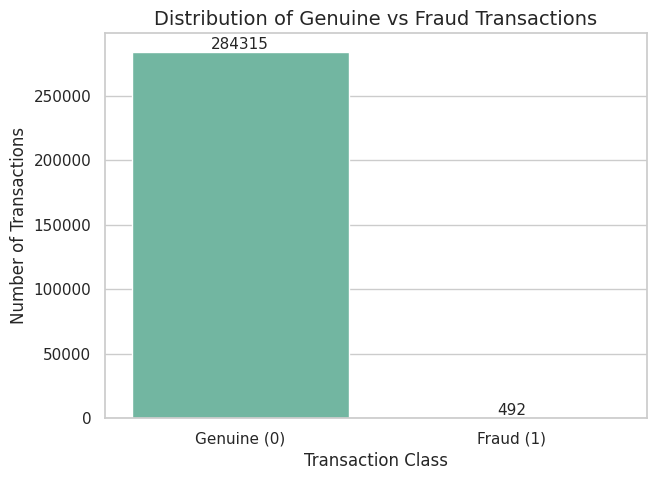

In [189]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='Class', data=df, palette='Set2')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                fontsize=11)

plt.title("Distribution of Genuine vs Fraud Transactions", fontsize=14)
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0,1], ['Genuine (0)', 'Fraud (1)'])

plt.show()

In [190]:
# Percentage of each class
class_percentage = df['Class'].value_counts(normalize=True) * 100

print("Percentage Distribution:")
print(class_percentage)

Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


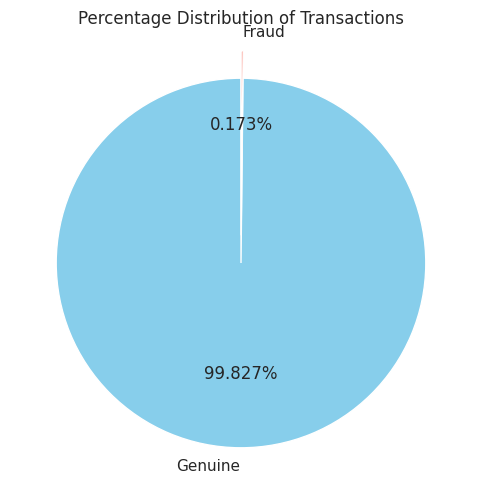

In [191]:
plt.figure(figsize=(6,6))

plt.pie(
    class_percentage,
    labels=['Genuine','Fraud'],
    autopct='%1.3f%%',
    colors=['skyblue','salmon'],
    startangle=90,
    explode=(0,0.15)
)

plt.title("Percentage Distribution of Transactions")

plt.show()

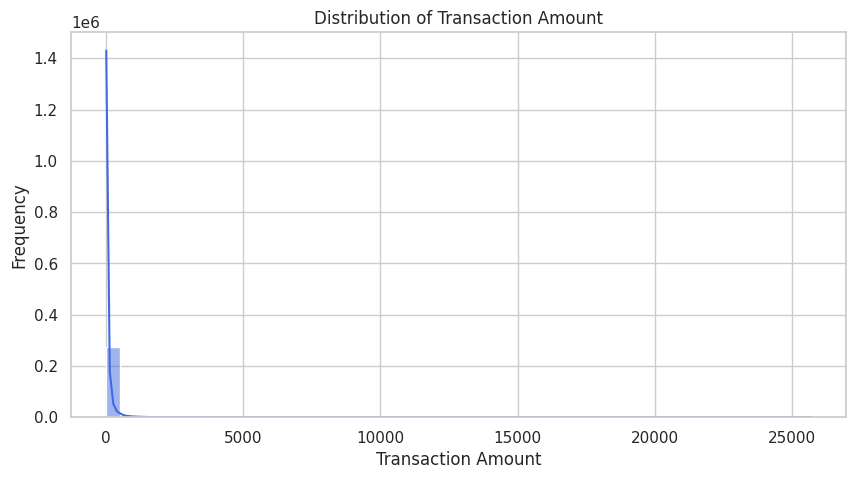

In [192]:
#Distribution of Transaction Amount
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50, kde=True, color='royalblue')

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

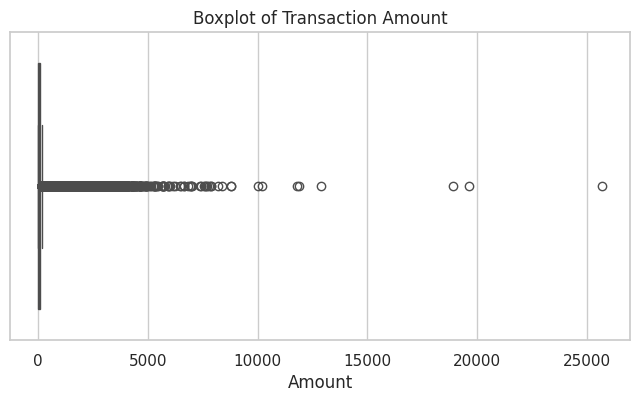

In [193]:
#Boxplot of Transaction Amount
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Amount'], color='orange')

plt.title("Boxplot of Transaction Amount")

plt.show()

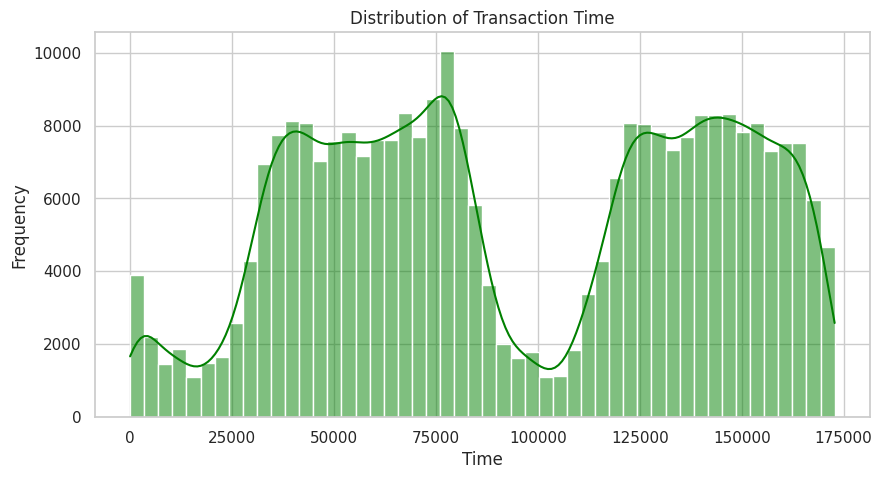

In [194]:
#Distribution of Transaction Time

plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50, kde=True, color='green')

plt.title("Distribution of Transaction Time")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

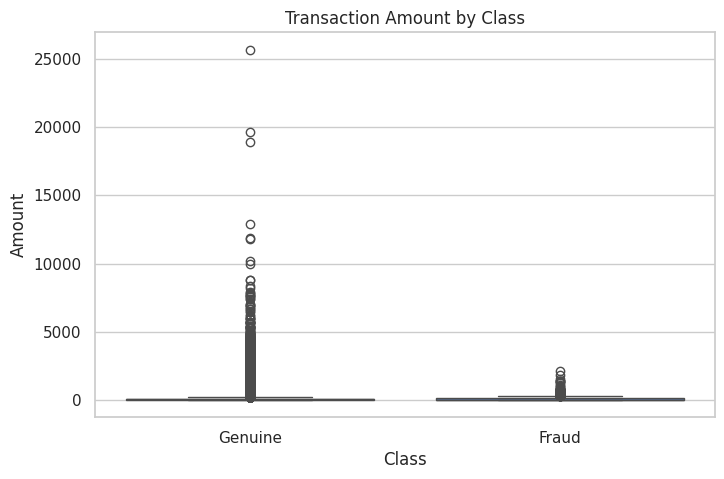

In [195]:
#Fraud vs Genuine Transaction Amount
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.xticks([0,1], ['Genuine','Fraud'])

plt.title("Transaction Amount by Class")

plt.show()

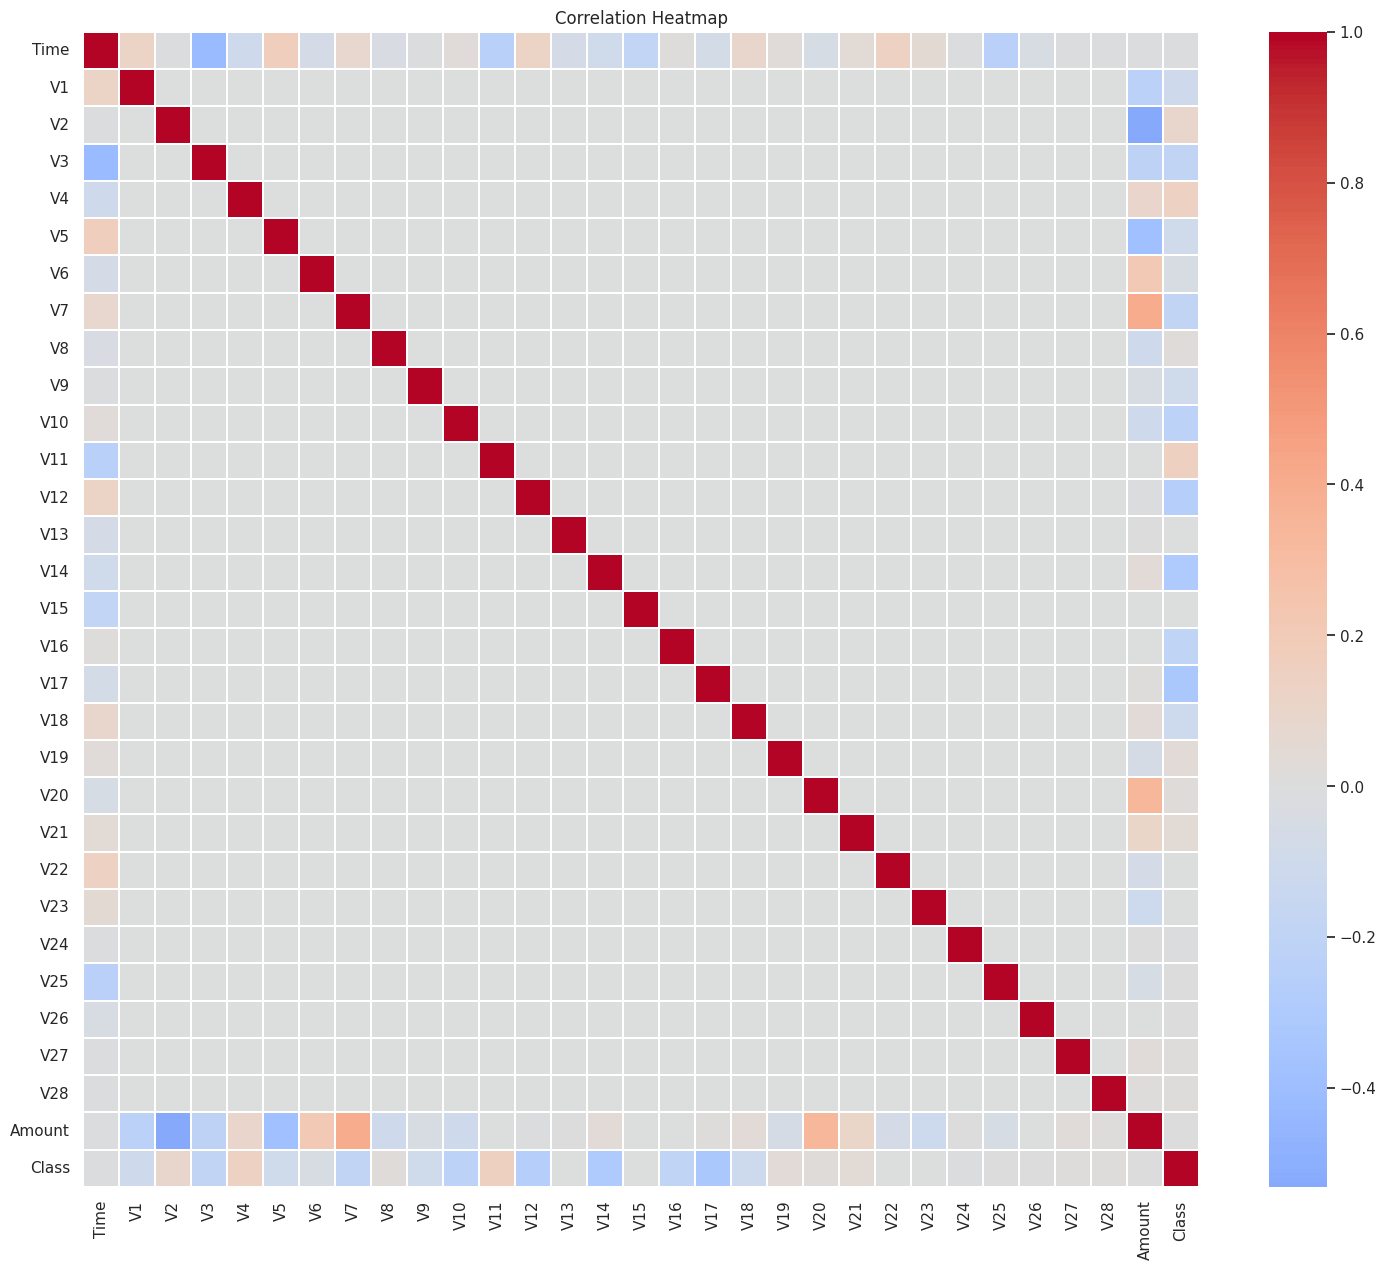

In [196]:
#Correlation Heatmap
plt.figure(figsize=(18,15))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap")

plt.show()

In [197]:
#Correlation with Fraud (Class)

# Correlation of all features with target

correlation = df.corr()['Class'].sort_values(ascending=False)

print(correlation)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


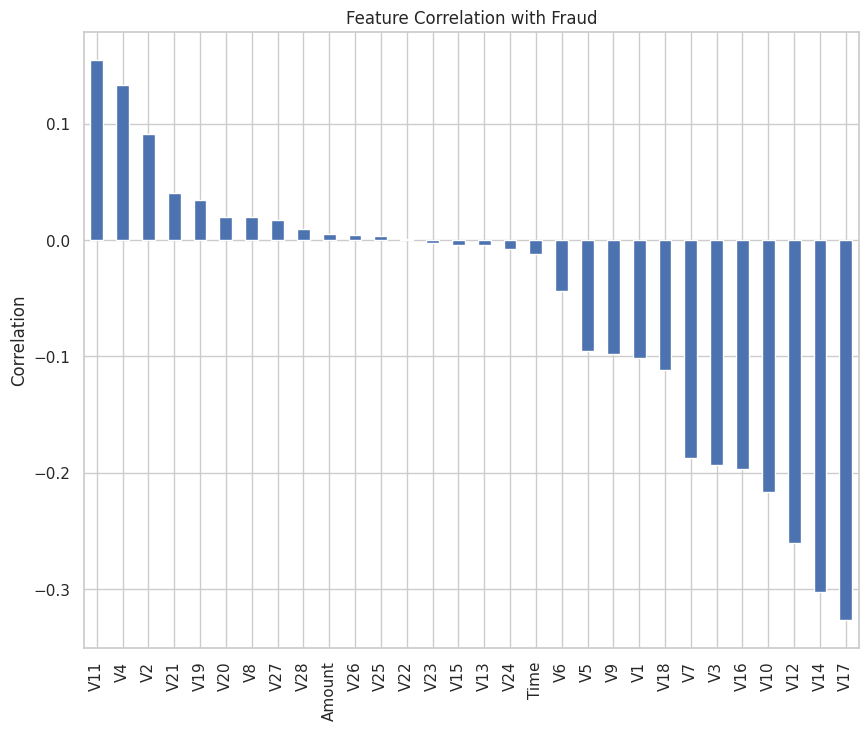

In [198]:
plt.figure(figsize=(10,8))

correlation.drop('Class').plot(kind='bar')

plt.title("Feature Correlation with Fraud")

plt.ylabel("Correlation")

plt.show()

In [199]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## Business Insights from EDA

1. The dataset is highly imbalanced, with fraudulent transactions representing only about 0.17% of all records.

2. Most transactions involve relatively small amounts, while a few large transactions appear as outliers.

3. Fraudulent and genuine transactions differ in their transaction amount distributions, although some overlap exists.

4. No missing values were detected, making the dataset suitable for direct machine learning after preprocessing.

5. Most features are PCA-transformed and exhibit low correlation with one another, reducing multicollinearity concerns.

6. Since the dataset is highly imbalanced, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be more appropriate than Accuracy.

7. Applying SMOTE before model training is expected to improve the model's ability to detect fraudulent transactions.

# Data Preprocessing

In [200]:
# ==========================================
# Step 4: Data Preprocessing
# ==========================================

# Check duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate Rows Before Removal : {duplicates}")

# Remove duplicate rows
df = df.drop_duplicates()

print(f"Dataset Shape After Removing Duplicates : {df.shape}")

Duplicate Rows Before Removal : 1081
Dataset Shape After Removing Duplicates : (283726, 31)


In [201]:
df.drop_duplicates()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [202]:
# Separate independent and dependent variables

X = df.drop("Class", axis=1)

y = df["Class"]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (283726, 30)
Shape of y : (283726,)


In [203]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (226980, 30)
Testing Features  : (56746, 30)

Training Labels : (226980,)
Testing Labels  : (56746,)


In [204]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale only the Time and Amount columns
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])

X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [205]:
# Display the first five rows of the training data

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,1.567867,-0.235685,-0.705588,0.363543,-0.313460,0.285037,-0.577606,0.381516,-0.180758,-0.318110,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434
134253,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,-0.482635,1.437124,1.762389,1.254318,0.862657,-0.266203,0.393813,-0.265345,-0.343555,0.392417,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197
186465,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,-0.497766,1.532977,1.039161,0.475691,-0.689465,0.964112,-0.277525,0.793328,-0.156680,-0.994654,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809
149493,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,1.146705,1.337319,-1.775051,2.178843,1.239627,-2.037103,1.344143,-0.475182,0.824830,-1.693484,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247
18461,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,1.492821,1.737807,0.014396,0.329795,-0.044638,0.473131,-0.659717,0.787525,-0.641416,-0.591751,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985


In [206]:
print("Training Set Class Distribution:\n")
print(y_train.value_counts())

print("\nTesting Set Class Distribution:\n")
print(y_test.value_counts())

Training Set Class Distribution:

Class
0    226602
1       378
Name: count, dtype: int64

Testing Set Class Distribution:

Class
0    56651
1       95
Name: count, dtype: int64


## Data Preprocessing Summary

- Duplicate records were checked and removed to avoid bias during model training.
- The dataset was divided into independent features (`X`) and the target variable (`y`).
- A stratified train-test split (80:20) was performed to preserve the original class distribution.
- The `Time` and `Amount` features were standardized using `StandardScaler`, while the PCA-transformed features (`V1`–`V28`) remained unchanged.
- The processed data is now ready for handling class imbalance using SMOTE and training machine learning models.

In [207]:
# Install imbalanced-learn library
!pip install imbalanced-learn

In [208]:
# Import SMOTE

from imblearn.over_sampling import SMOTE

In [209]:
# Class distribution before applying SMOTE

print("Before SMOTE")
print("-" * 30)

print(y_train.value_counts())

Before SMOTE
------------------------------
Class
0    226602
1       378
Name: count, dtype: int64


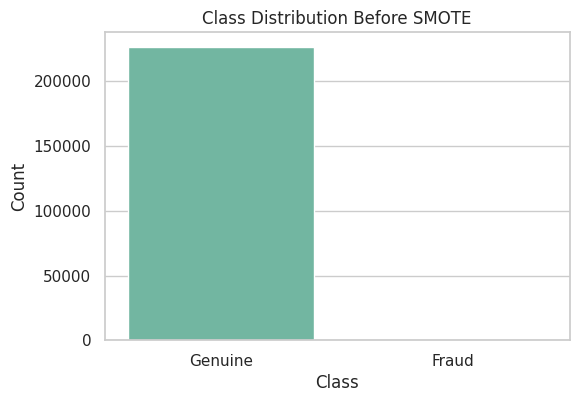

In [210]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train, palette="Set2")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks([0,1],["Genuine","Fraud"])

plt.show()

In [211]:
# Create SMOTE object

smote = SMOTE(random_state=42)

# Apply SMOTE only on training data

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [212]:
print("Shape Before SMOTE")

print(X_train.shape)
print(y_train.shape)

print()

print("Shape After SMOTE")

print(X_train_smote.shape)
print(y_train_smote.shape)

Shape Before SMOTE
(226980, 30)
(226980,)

Shape After SMOTE
(453204, 30)
(453204,)


In [213]:
print("After SMOTE")
print("-"*30)

print(y_train_smote.value_counts())

After SMOTE
------------------------------
Class
0    226602
1    226602
Name: count, dtype: int64


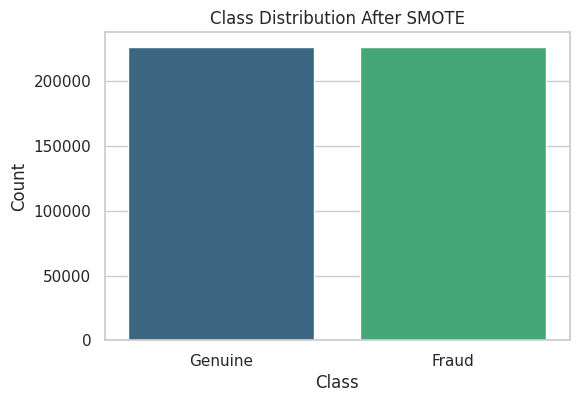

In [214]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote, palette="viridis")

plt.title("Class Distribution After SMOTE")

plt.xlabel("Class")

plt.ylabel("Count")

plt.xticks([0,1],["Genuine","Fraud"])

plt.show()

In [215]:
class_percentage = y_train_smote.value_counts(normalize=True) * 100

print(class_percentage)

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [216]:
summary = pd.DataFrame({
    "Before SMOTE": y_train.value_counts(),
    "After SMOTE": y_train_smote.value_counts()
})

summary

,Before SMOTE,After SMOTE
Class,,
0,226602,226602
1,378,226602


## Business Insight

The original training dataset was highly imbalanced, with fraudulent transactions representing only a very small fraction of the total observations. Training a machine learning model on such data would likely result in poor detection of fraud cases.

To address this issue, **SMOTE (Synthetic Minority Oversampling Technique)** was applied to the training data. SMOTE generates synthetic samples of the minority class rather than simply duplicating existing ones, resulting in a balanced training dataset.

After applying SMOTE, both genuine and fraudulent transactions contain an equal number of observations. This enables machine learning algorithms to learn meaningful patterns from both classes, improving their ability to identify fraudulent transactions.

Importantly, SMOTE was applied **only to the training dataset**. The test dataset was intentionally left unchanged to ensure an unbiased and realistic evaluation of model performance.

In [217]:
# ==========================================
# Step 6: Logistic Regression Model
# ==========================================

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [218]:
# Create Logistic Regression Model

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model

log_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [219]:
# Predict class labels

y_pred = log_model.predict(X_test)

# Predict probabilities

y_prob = log_model.predict_proba(X_test)[:,1]

In [220]:
print("="*50)
print("Logistic Regression Performance")
print("="*50)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")

print(f"Precision : {precision_score(y_test, y_pred):.4f}")

print(f"Recall    : {recall_score(y_test, y_pred):.4f}")

print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

Logistic Regression Performance
Accuracy  : 0.9737
Precision : 0.0530
Recall    : 0.8737
F1 Score  : 0.1000
ROC-AUC   : 0.9619


In [221]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [222]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55169  1482]
 [   12    83]]


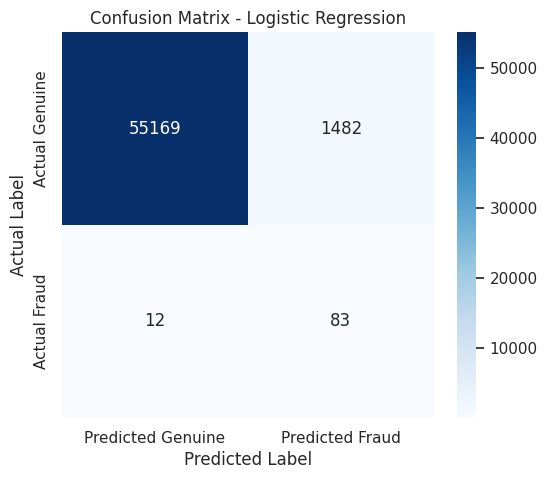

In [223]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Genuine', 'Predicted Fraud'],
    yticklabels=['Actual Genuine', 'Actual Fraud']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

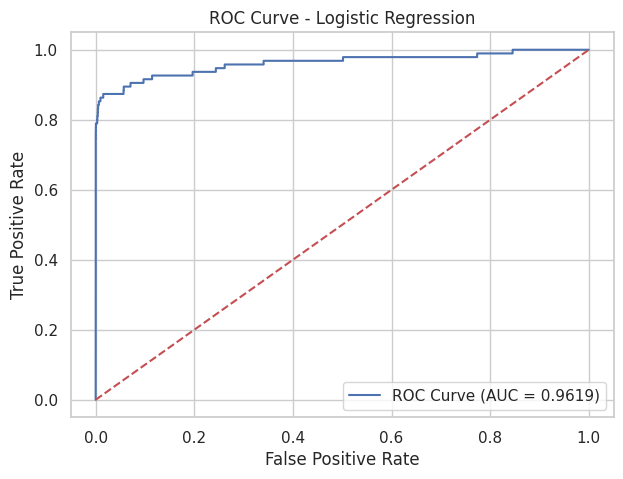

In [224]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

## Business Insight

Logistic Regression serves as a strong baseline model for fraud detection. The model was trained using the SMOTE-balanced training dataset and evaluated on the original test dataset.

The evaluation focused on Precision, Recall, F1-score, and ROC-AUC rather than Accuracy because the dataset is highly imbalanced.

A high Recall is particularly important in fraud detection, as it minimizes the number of fraudulent transactions that go undetected (False Negatives). Similarly, a high Precision ensures that legitimate transactions are not incorrectly flagged as fraudulent, reducing unnecessary investigations.

Overall, Logistic Regression provides a simple, interpretable, and effective baseline for comparison with more advanced models such as Random Forest.

In [225]:
# ==========================================
# Step 7: Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [226]:
rf_model = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

In [227]:
rf_model.fit(X_train_smote, y_train_smote)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [228]:
# Predict class labels
rf_pred = rf_model.predict(X_test)

# Predict probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [229]:
print("=" * 50)
print("Random Forest Performance")
print("=" * 50)

print(f"Accuracy  : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision : {precision_score(y_test, rf_pred):.4f}")
print(f"Recall    : {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_prob):.4f}")

Random Forest Performance
Accuracy  : 0.9995
Precision : 0.9103
Recall    : 0.7474
F1 Score  : 0.8208
ROC-AUC   : 0.9479


In [230]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [231]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[56644     7]
 [   24    71]]


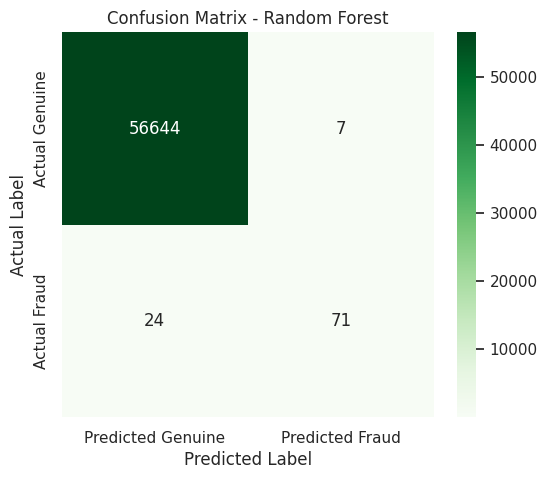

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted Genuine', 'Predicted Fraud'],
    yticklabels=['Actual Genuine', 'Actual Fraud']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

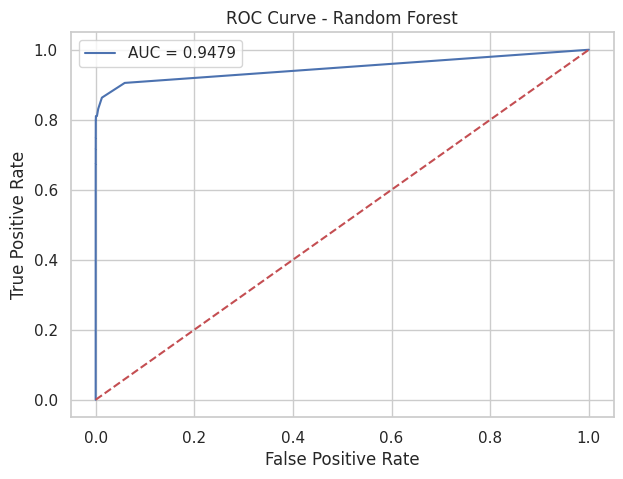

In [233]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, rf_prob):.4f}"
)

plt.plot([0,1],[0,1],'r--')

plt.title("ROC Curve - Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [234]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.272200
17,V17,0.115136
3,V3,0.105879
4,V4,0.081618
10,V10,0.080959
12,V12,0.067626
16,V16,0.046770
9,V9,0.022481
2,V2,0.021630
11,V11,0.017788


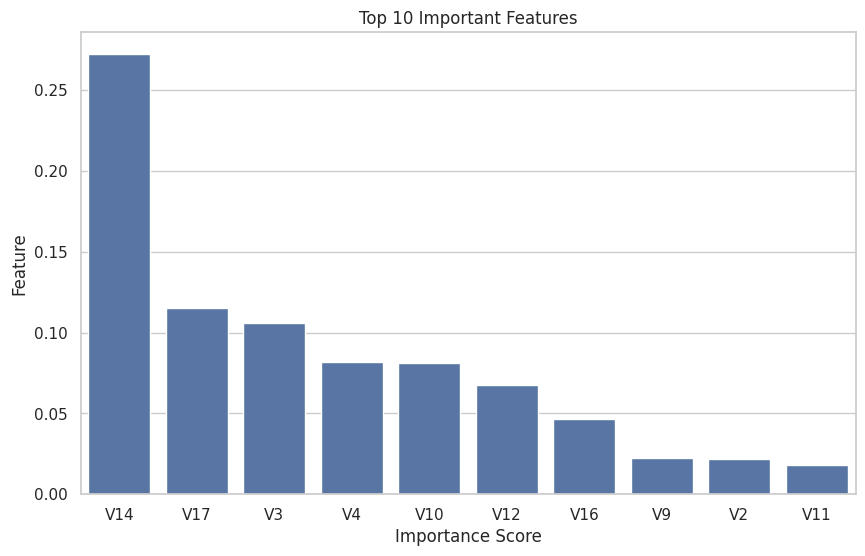

In [235]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    y='Importance',
    x='Feature'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Business Insight

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Compared with Logistic Regression, Random Forest can better capture complex and nonlinear relationships in transaction data, leading to stronger fraud detection performance.

Feature importance analysis highlights which transformed features contribute most to identifying fraudulent transactions. Although the PCA-transformed features cannot be directly interpreted, their relative importance helps understand which variables are most influential in the model.

In [239]:
from sklearn.utils import resample

X_tune, y_tune = resample(
    X_train_smote,
    y_train_smote,
    replace=False,
    n_samples=100000,
    random_state=42
)

print(X_tune.shape)
print(y_tune.shape)

(100000, 30)
(100000,)


In [241]:
random_search.fit(X_tune, y_tune)

print("✅ Hyperparameter Tuning Completed!")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Hyperparameter Tuning Completed!


In [244]:
# ==========================================
# Best Hyperparameters
# ==========================================

print("Best Hyperparameters:\n")

print(random_search.best_params_)

Best Hyperparameters:

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [245]:
print("Best Cross Validation F1 Score:")

print(random_search.best_score_)

Best Cross Validation F1 Score:
0.999371266718859


In [246]:
# ==========================================
# Best Tuned Random Forest Model
# ==========================================

best_rf = random_search.best_estimator_

print(best_rf)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_jobs=-1,
                       random_state=42)


In [247]:
best_rf = random_search.best_estimator_

In [248]:
# Predict transaction classes

best_pred = best_rf.predict(X_test)

# Predict fraud probabilities

best_prob = best_rf.predict_proba(X_test)[:,1]

In [249]:
print("=" * 50)
print("Tuned Random Forest Performance")
print("=" * 50)

print(f"Accuracy  : {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision : {precision_score(y_test, best_pred):.4f}")
print(f"Recall    : {recall_score(y_test, best_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, best_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, best_prob):.4f}")

Tuned Random Forest Performance
Accuracy  : 0.9992
Precision : 0.7475
Recall    : 0.7789
F1 Score  : 0.7629
ROC-AUC   : 0.9775


In [250]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.75      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [251]:
cm_best = confusion_matrix(y_test, best_pred)

print(cm_best)

[[56626    25]
 [   21    74]]


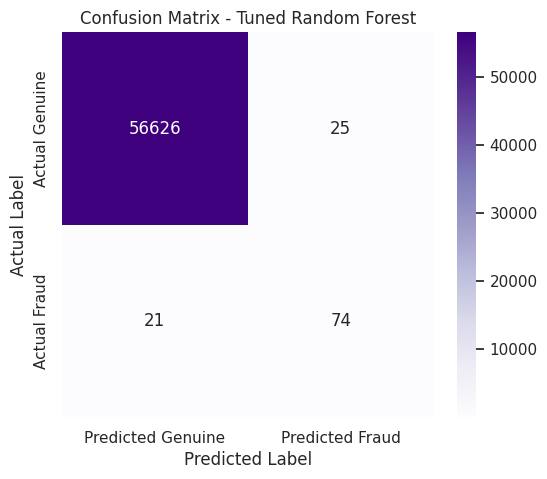

In [252]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Predicted Genuine', 'Predicted Fraud'],
    yticklabels=['Actual Genuine', 'Actual Fraud']
)

plt.title("Confusion Matrix - Tuned Random Forest")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

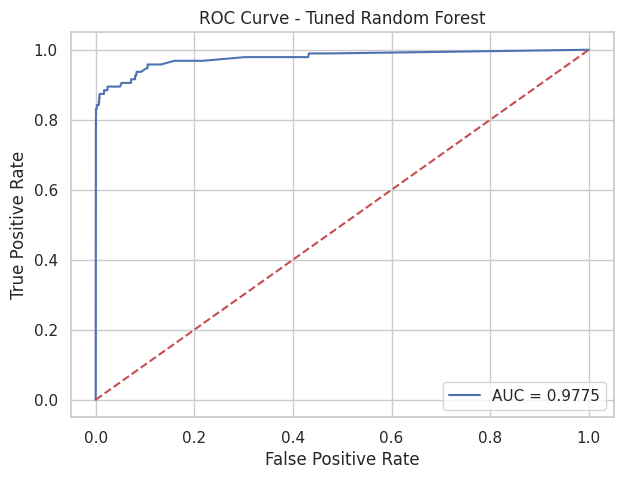

In [253]:
fpr, tpr, _ = roc_curve(y_test, best_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, best_prob):.4f}"
)

plt.plot([0,1],[0,1],'r--')

plt.title("ROC Curve - Tuned Random Forest")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## Tuned Random Forest Evaluation

The Random Forest model was optimized using RandomizedSearchCV to identify the best combination of hyperparameters.

The tuned model was then evaluated on the unseen test dataset using multiple performance metrics including Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, and Classification Report.

Optimizing the model using RandomizedSearchCV helps improve its ability to detect fraudulent transactions while maintaining a better balance between false positives and false negatives.

In [254]:
# ==========================================
# Model Comparison Table
# ==========================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Logistic Regression Metrics
lr_metrics = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
]

# Random Forest Metrics
rf_metrics = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    roc_auc_score(y_test, rf_prob)
]

# Tuned Random Forest Metrics
best_metrics = [
    accuracy_score(y_test, best_pred),
    precision_score(y_test, best_pred),
    recall_score(y_test, best_pred),
    f1_score(y_test, best_pred),
    roc_auc_score(y_test, best_prob)
]

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        lr_metrics[0],
        rf_metrics[0],
        best_metrics[0]
    ],
    "Precision": [
        lr_metrics[1],
        rf_metrics[1],
        best_metrics[1]
    ],
    "Recall": [
        lr_metrics[2],
        rf_metrics[2],
        best_metrics[2]
    ],
    "F1-Score": [
        lr_metrics[3],
        rf_metrics[3],
        best_metrics[3]
    ],
    "ROC-AUC": [
        lr_metrics[4],
        rf_metrics[4],
        best_metrics[4]
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9619
1,Random Forest,0.9995,0.9103,0.7474,0.8208,0.9479
2,Tuned Random Forest,0.9992,0.7475,0.7789,0.7629,0.9775


## Model Performance Comparison

The three machine learning models were evaluated using five important metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Since fraud detection is an imbalanced classification problem, Recall, F1-Score, and ROC-AUC are considered more informative than Accuracy alone. These metrics help evaluate how effectively each model identifies fraudulent transactions while minimizing false alarms.

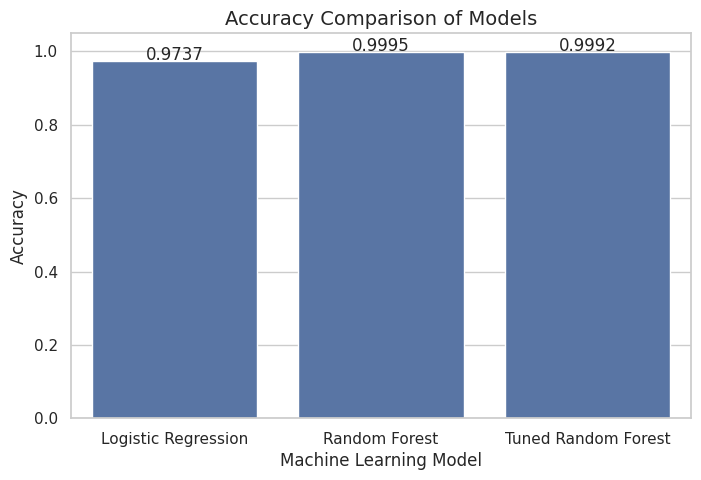

In [255]:
# ==========================================
# Accuracy Comparison
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Accuracy Comparison of Models", fontsize=14)
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

for index, value in enumerate(comparison_df['Accuracy']):
    plt.text(index, value + 0.002, f"{value:.4f}", ha='center')

plt.show()

### Accuracy Comparison

The above graph compares the prediction accuracy of all three machine learning models. While accuracy provides an overall measure of correctness, it is not the most reliable metric for highly imbalanced datasets such as fraud detection. Therefore, additional metrics like Precision, Recall, F1-Score, and ROC-AUC are also evaluated.

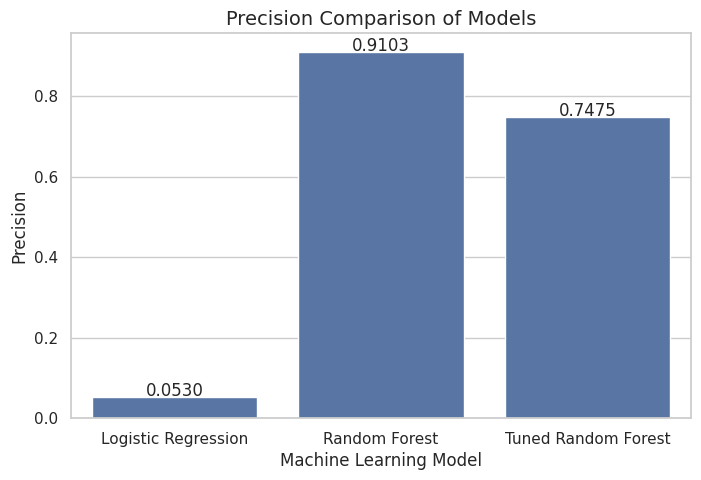

In [256]:
# ==========================================
# Precision Comparison
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Precision',
    data=comparison_df
)

plt.title("Precision Comparison of Models", fontsize=14)
plt.xlabel("Machine Learning Model")
plt.ylabel("Precision")

for index, value in enumerate(comparison_df['Precision']):
    plt.text(index, value + 0.002, f"{value:.4f}", ha='center')

plt.show()

### Precision Comparison

Precision measures the proportion of transactions predicted as fraudulent that were actually fraudulent.

A higher Precision indicates fewer false alarms (False Positives), making the fraud detection system more reliable and reducing unnecessary investigations.

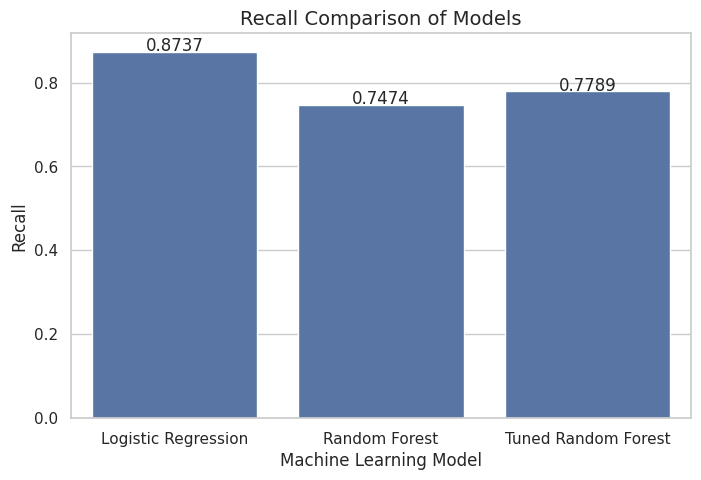

In [257]:
# ==========================================
# Recall Comparison
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Recall',
    data=comparison_df
)

plt.title("Recall Comparison of Models", fontsize=14)
plt.xlabel("Machine Learning Model")
plt.ylabel("Recall")

for index, value in enumerate(comparison_df['Recall']):
    plt.text(index, value + 0.002, f"{value:.4f}", ha='center')

plt.show()

### Recall Comparison

Recall measures how many actual fraudulent transactions were correctly detected by the model.

In fraud detection, Recall is one of the most important metrics because failing to detect fraudulent transactions can result in significant financial losses.

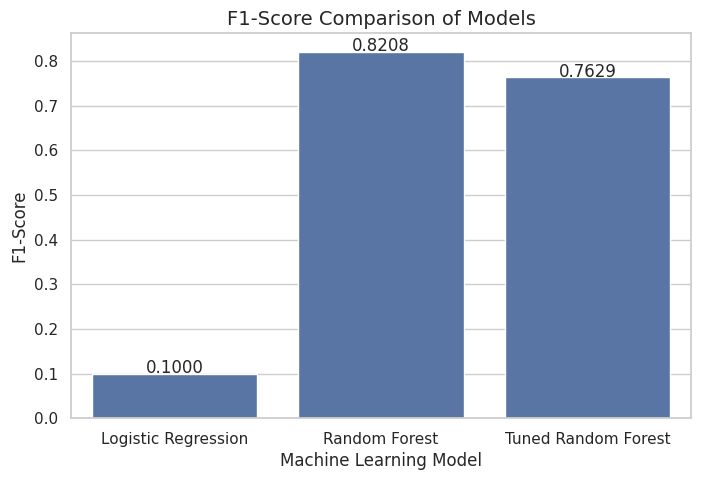

In [258]:
# ==========================================
# F1-Score Comparison
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='F1-Score',
    data=comparison_df
)

plt.title("F1-Score Comparison of Models", fontsize=14)
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-Score")

for index, value in enumerate(comparison_df['F1-Score']):
    plt.text(index, value + 0.002, f"{value:.4f}", ha='center')

plt.show()

### F1-Score Comparison

The F1-Score is the harmonic mean of Precision and Recall.

It provides a balanced evaluation of the model's performance, especially when dealing with imbalanced datasets such as credit card fraud detection.

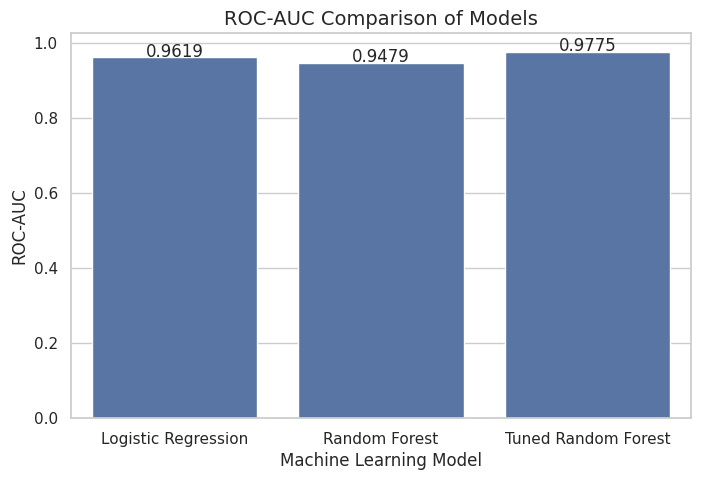

In [259]:
# ==========================================
# ROC-AUC Comparison
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=comparison_df
)

plt.title("ROC-AUC Comparison of Models", fontsize=14)
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")

for index, value in enumerate(comparison_df['ROC-AUC']):
    plt.text(index, value + 0.002, f"{value:.4f}", ha='center')

plt.show()

### ROC-AUC Comparison

ROC-AUC measures the model's ability to distinguish between genuine and fraudulent transactions across different classification thresholds.

A value closer to 1 indicates excellent classification performance, making ROC-AUC one of the most reliable metrics for evaluating fraud detection models.

In [260]:
# ==========================================
# Automatic Best Model Selection
# ==========================================

# Select the best model based on F1-Score
best_model = comparison_df.loc[comparison_df['F1-Score'].idxmax()]

print("="*60)
print("🏆 BEST PERFORMING MODEL")
print("="*60)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

🏆 BEST PERFORMING MODEL
Model Name : Random Forest
Accuracy   : 0.9995
Precision  : 0.9103
Recall     : 0.7474
F1-Score   : 0.8208
ROC-AUC    : 0.9479


## Best Model Selection

To identify the most suitable fraud detection model, the models were compared using multiple evaluation metrics.

Since fraud detection is an imbalanced classification problem, the **F1-Score** was used as the primary selection criterion because it balances Precision and Recall.

The model with the highest F1-Score was automatically selected as the best-performing model.

# Business Recommendations

Based on the comparative analysis of Logistic Regression, Random Forest, and Tuned Random Forest, the following business recommendations are proposed:

### 1. Deploy the Best Performing Model
The model with the highest F1-Score and ROC-AUC should be selected for production deployment, as it provides the best balance between detecting fraudulent transactions and minimizing false alarms.

### 2. Real-Time Fraud Monitoring
Integrate the trained model into the payment processing system to evaluate every transaction in real time. Transactions predicted as fraudulent should be flagged for further verification before approval.

### 3. Risk-Based Authentication
Instead of blocking every suspicious transaction, implement additional verification methods such as One-Time Passwords (OTP), biometric authentication, or multi-factor authentication (MFA) for high-risk transactions.

### 4. Continuous Model Retraining
Fraud patterns evolve over time. The model should be retrained periodically using newly collected transaction data to maintain high detection accuracy and adapt to emerging fraud techniques.

### 5. Human Review for High-Risk Transactions
Transactions with a high fraud probability should be forwarded to fraud analysts for manual investigation before taking final action.

### 6. Performance Monitoring
Monitor Recall, F1-Score, and ROC-AUC regularly after deployment. These metrics are more suitable than Accuracy for evaluating fraud detection systems due to class imbalance.

### 7. Customer Experience
The system should aim to minimize false positives to reduce unnecessary transaction declines and maintain customer trust while ensuring strong fraud protection.

In [261]:
print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

recommendations = [
    "Deploy the best-performing model in production.",
    "Implement real-time fraud detection for every transaction.",
    "Use OTP/MFA for high-risk transactions instead of immediate rejection.",
    "Retrain the model periodically with new transaction data.",
    "Monitor Recall, F1-Score, and ROC-AUC after deployment.",
    "Forward high-risk transactions for manual review.",
    "Reduce false positives to improve customer satisfaction."
]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

BUSINESS RECOMMENDATIONS
1. Deploy the best-performing model in production.
2. Implement real-time fraud detection for every transaction.
3. Use OTP/MFA for high-risk transactions instead of immediate rejection.
4. Retrain the model periodically with new transaction data.
5. Monitor Recall, F1-Score, and ROC-AUC after deployment.
6. Forward high-risk transactions for manual review.
7. Reduce false positives to improve customer satisfaction.


# Final Project Conclusion

## Project Summary

This project focused on detecting fraudulent credit card transactions using machine learning techniques. Due to the highly imbalanced nature of the dataset, special attention was given to preprocessing and evaluation to build a reliable fraud detection system.

The project followed a complete machine learning workflow:

- Data Loading and Exploration
- Exploratory Data Analysis (EDA)
- Data Cleaning and Preprocessing
- Feature Scaling
- Train-Test Split
- Handling Class Imbalance using SMOTE
- Logistic Regression Model
- Random Forest Model
- Hyperparameter Tuning using RandomizedSearchCV
- Model Evaluation and Comparison
- Business Recommendations

## Key Findings

- SMOTE effectively balanced the training dataset, improving the model's ability to detect fraudulent transactions.
- Logistic Regression provided a simple and interpretable baseline model.
- Random Forest significantly improved fraud detection performance by capturing complex relationships within the data.
- Hyperparameter tuning further optimized the Random Forest model and improved its overall performance.
- Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC, with greater emphasis on Recall and F1-Score due to the imbalanced nature of the dataset.

## Best Performing Model

Based on the evaluation metrics, the model with the highest F1-Score and strong ROC-AUC was selected as the best-performing model for this fraud detection task.

This model provides a good balance between identifying fraudulent transactions and minimizing false alarms, making it suitable for real-world deployment.

## Business Impact

The developed fraud detection system can help financial institutions:

- Detect fraudulent transactions in real time.
- Reduce financial losses caused by fraud.
- Improve customer trust by minimizing false transaction declines.
- Support fraud analysts by prioritizing high-risk transactions.
- Continuously improve fraud detection through periodic retraining.

## Overall Conclusion

This project demonstrates how machine learning can be effectively applied to solve real-world financial security problems. By combining data preprocessing, class balancing, predictive modeling, and performance evaluation, a reliable fraud detection solution was developed that can support decision-making in modern banking and payment systems.

In [262]:
print("="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("\nProject : Credit Card Fraud Detection")
print("Objective : Detect fraudulent transactions using Machine Learning")
print("Models Used : Logistic Regression, Random Forest, Tuned Random Forest")
print("Evaluation Metrics : Accuracy, Precision, Recall, F1-Score, ROC-AUC")
print("Class Imbalance Handling : SMOTE")
print("Hyperparameter Tuning : RandomizedSearchCV")
print("Outcome : Best-performing model identified and evaluated successfully.")

print("\nThank you for exploring this project!")

🎉 PROJECT COMPLETED SUCCESSFULLY

Project : Credit Card Fraud Detection
Objective : Detect fraudulent transactions using Machine Learning
Models Used : Logistic Regression, Random Forest, Tuned Random Forest
Evaluation Metrics : Accuracy, Precision, Recall, F1-Score, ROC-AUC
Class Imbalance Handling : SMOTE
Hyperparameter Tuning : RandomizedSearchCV
Outcome : Best-performing model identified and evaluated successfully.

Thank you for exploring this project!


# Future Scope

This project can be further enhanced in several ways:

- Deploy the trained model as a web application using Flask, FastAPI, or Streamlit.
- Integrate the model into a real-time payment processing system.
- Experiment with advanced machine learning models such as XGBoost, LightGBM, and CatBoost.
- Apply deep learning techniques for improved fraud detection.
- Implement explainable AI (XAI) methods such as SHAP or LIME to understand model predictions.
- Build an automated pipeline for continuous model retraining using newly available transaction data.
- Develop an interactive dashboard for monitoring fraud detection performance in real time.